In [1]:
from matplotlib.ticker import LinearLocator
import numpy as np
import matplotlib.pyplot as plt
import time
from jax import vmap
import sys
import jax

jax.config.update("jax_platform_name", "cpu")


sys.path.append("..")


# from utils.integrate import leggauss

In [2]:
from configuration.rte1d_settings import get_config

start_time = time.time()
rte_config = get_config()
domain = dict(rte_config.mesh["domain"])
kn = 1e-1  # rte_config.model.knudsen_number
num_quads = rte_config.model.num_quads
fn_sigma_s = rte_config.model.coeff["scattering"]
fn_sigma_a = rte_config.model.coeff["absorption"]


def fn_source(x, v):
    return np.zeros_like(v)


# def fn_source(x, v):
#     return -v / kn


fn_l = rte_config.model.bdy_cond["f_l"]
fn_r = rte_config.model.bdy_cond["f_r"]
num_x, num_v = rte_config.model.grid_sizes  # num_v % 2 == 0
print(f"num_x = {num_x}, num_v = {num_v}")
(xmin, xmax), (vmin, vmax) = domain["x"], domain["v"]
dx = (xmax - xmin) / num_x
kn_dx = kn / dx
mesh_x = np.linspace(xmin, xmax, num_x + 1)
mesh_xc = np.linspace(
    xmin + dx / 2, xmax - dx / 2, num_x
)  # num_x pts in cell center (not include gohst points)
# x, xc
# quadratures = leggauss(num_v)
# mesh_v, weights = quadratures
# mesh_v = mesh_v.squeeze()
# weights = weights.squeeze()
mesh_v = np.linspace(vmin, vmax, num_v)
weights = np.ones((num_v,)) * (vmax - vmin) / (num_v - 1)
v_pos = mesh_v[mesh_v > 0]
v_neg = mesh_v[mesh_v < 0]
vector_sigma_s = np.asarray(vmap(fn_sigma_s)(mesh_xc))[:, None]  # (num_x, 1)
vector_sigma_t = np.asarray(
    vmap(fn_sigma_s)(mesh_xc)[:, None] + kn**2 *
    vmap(fn_sigma_a)(mesh_xc)[:, None]
)
# vector_source = np.asarray(vmap(fn_source)(mesh_xc))[:, None]
X, V = np.meshgrid(mesh_xc, mesh_v, indexing="ij")  # shape = (num_x, num_v)
vector_source = fn_source(X, V)  # shape = (num_x, num_v)

matrix_f = np.ones((num_x + 1, num_v))
matrix_fc = np.zeros((num_x, num_v))
matrix_f[0, mesh_v > 0] = np.asarray(vmap(fn_l)(v_pos))
matrix_f[-1, mesh_v < 0] = np.asarray(vmap(fn_r)(v_neg))

num_x = 1024, num_v = 2048


In [3]:
def compute_q(matrix_f, weights, vector_sigma_s, vector_source, kn):
    matrix_fc = 0.5 * (matrix_f[1:] + matrix_f[:-1])  # shape (num_x, num_v)
    avg = 0.5 * matrix_fc @ weights[:, None]  # shape (num_x, 1)
    q = vector_sigma_s * avg + kn**2 * vector_source  # shape (num_x, num_v)
    return q

In [4]:
def source_iteration(matrix_f):
    F = matrix_f.copy()
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(-1, -num_x - 1, -1):
        F[i - 1, mesh_v < 0] = (
            q[i, mesh_v < 0] / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            - (0.5 * vector_sigma_t[i, 0] + kn_dx * v_neg)
            / (0.5 * vector_sigma_t[i, 0] - kn_dx * v_neg)
            * F[i, mesh_v < 0]
        )
    q = compute_q(F, weights, vector_sigma_s, vector_source, kn)
    for i in range(num_x):
        F[i + 1, mesh_v > 0] = (
            q[i, mesh_v > 0] / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            - (0.5 * vector_sigma_t[i, 0] - kn_dx * v_pos)
            / (0.5 * vector_sigma_t[i, 0] + kn_dx * v_pos)
            * F[i, mesh_v > 0]
        )
    return F

In [5]:
def dvm_solver(
    matrix_f: np.array, tol: float = 1e-8, max_iter: int = 2**14
) -> np.array:
    for i in range(max_iter):
        matrix_f_new = source_iteration(matrix_f)
        diff = np.linalg.norm(matrix_f_new - matrix_f)
        print(f"Iter {i + 1}: difference = {diff:.4e}")
        if diff < tol:
            print(f"converged at iter {i + 1}")
            break
        matrix_f = matrix_f_new
    return matrix_f

In [6]:
matrix_f = dvm_solver(matrix_f)
end_time = time.time()
print(f"time taken: {end_time - start_time} seconds")

Iter 1: difference = 1.6691e+02
Iter 2: difference = 8.0841e+01
Iter 3: difference = 5.6129e+01
Iter 4: difference = 4.4059e+01
Iter 5: difference = 3.6703e+01
Iter 6: difference = 3.1686e+01
Iter 7: difference = 2.8016e+01
Iter 8: difference = 2.5198e+01
Iter 9: difference = 2.2957e+01
Iter 10: difference = 2.1127e+01
Iter 11: difference = 1.9602e+01
Iter 12: difference = 1.8307e+01
Iter 13: difference = 1.7192e+01
Iter 14: difference = 1.6221e+01
Iter 15: difference = 1.5364e+01
Iter 16: difference = 1.4601e+01
Iter 17: difference = 1.3916e+01
Iter 18: difference = 1.3295e+01
Iter 19: difference = 1.2728e+01
Iter 20: difference = 1.2207e+01
Iter 21: difference = 1.1724e+01
Iter 22: difference = 1.1275e+01
Iter 23: difference = 1.0855e+01
Iter 24: difference = 1.0460e+01
Iter 25: difference = 1.0087e+01
Iter 26: difference = 9.7338e+00
Iter 27: difference = 9.3981e+00
Iter 28: difference = 9.0781e+00
Iter 29: difference = 8.7725e+00
Iter 30: difference = 8.4799e+00
Iter 31: difference

In [7]:
X, V = np.meshgrid(mesh_x[1:-1], mesh_v[1:-1])
F = matrix_f[1:-1, 1:-1]

rho = 0.5 * (F @ weights[1:-1][:, None]).squeeze()
F = F.T

绘制分开的边界图:


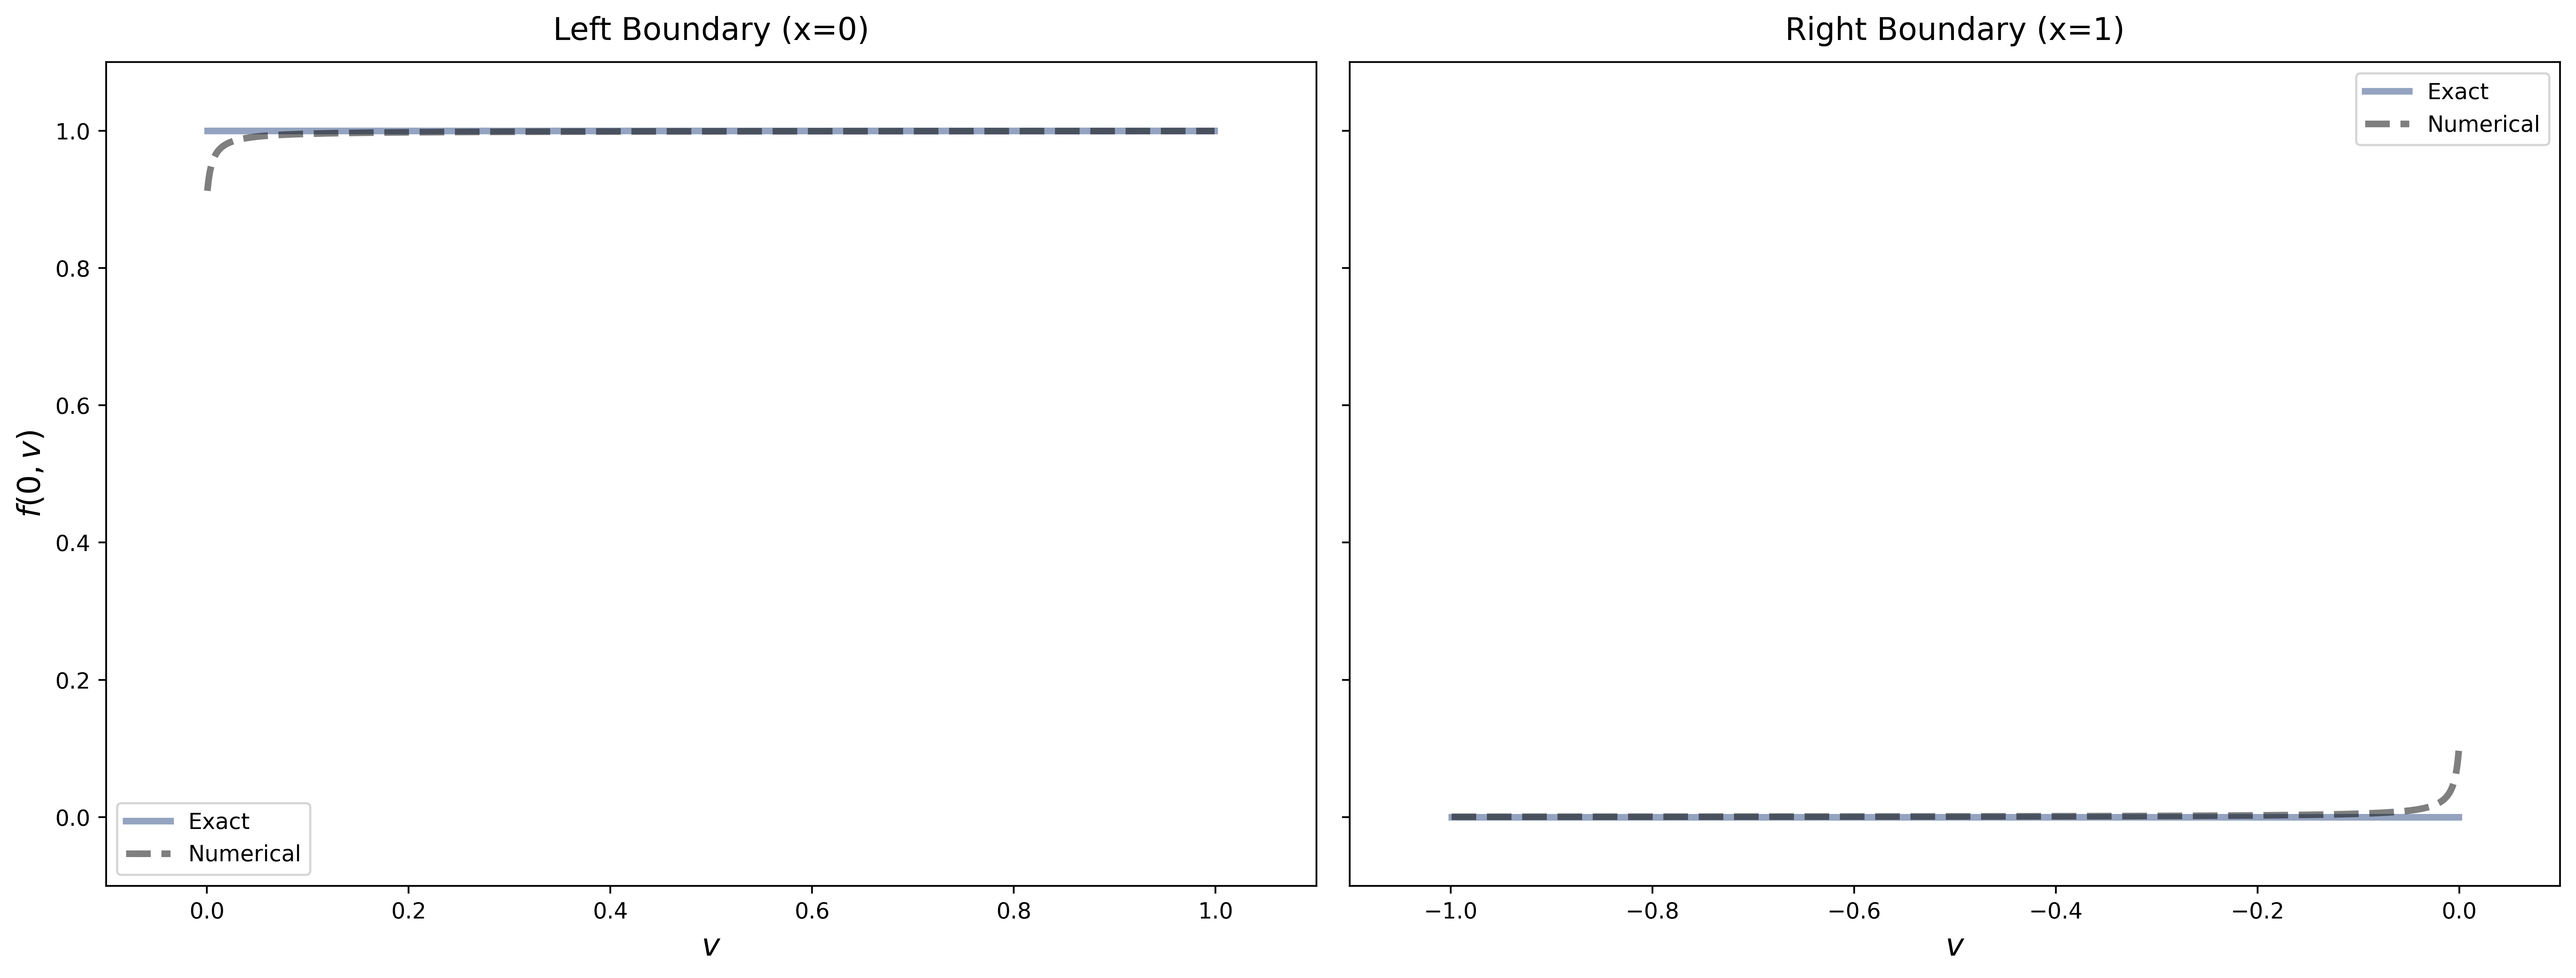

In [8]:
def plot_boundary_solutions_separate_modified():
    """分别绘制左右边界的解 - 清晰的一行两列布局"""
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(16, 6), dpi=500, sharey=True, constrained_layout=True
    )

    # 提取左边界数据 (v > 0)
    Vl = mesh_v[1:-1][mesh_v[1:-1] > 0]
    Fl = F[mesh_v[1:-1] > 0, 0]
    fl = np.ones_like(Fl)   # 精确解

    # 提取右边界数据 (v < 0)
    Vr = mesh_v[1:-1][mesh_v[1:-1] < 0]
    Fr = F[mesh_v[1:-1] < 0, -1]
    fr = np.zeros_like(Fr)  # 精确解

    # 左边界图
    ax1.plot(Vl, fl, "-", color="#94A3C0", linewidth=3, label="Exact")
    ax1.plot(Vl, Fl, "k--", alpha=0.5, linewidth=3, label="Numerical")
    ax1.set_xlim([-0.1, 1.1])
    ax1.set_ylim([-0.1, 1.1])
    ax1.set_xlabel(r"$v$", fontsize=14)
    ax1.set_ylabel(r"$f(0, v)$", fontsize=14)
    ax1.set_title("Left Boundary (x=0)", fontsize=14, pad=10)
    ax1.legend(frameon=True, loc="best")

    # 右边界图
    ax2.plot(Vr, fr, "-", color="#94A3C0", linewidth=3, label="Exact")
    ax2.plot(Vr, Fr, "k--", alpha=0.5, linewidth=3, label="Numerical")
    ax2.set_xlim([-1.1, 0.1])
    ax2.set_ylim([-0.1, 1.1])
    ax2.set_xlabel(r"$v$", fontsize=14)
    ax2.set_title("Right Boundary (x=1)", fontsize=14, pad=10)
    ax2.legend(frameon=True, loc="best")

    # plt.suptitle(f"Distribution Function at Boundaries (kn={kn})",
    #              fontsize=16, y=1.02)
    plt.show()
    plt.close()


def print_boundary_error_modified():
    """计算并打印边界误差"""
    # 左边界误差
    Fl = F[mesh_v[1:-1] > 0, 0]
    fl = np.ones_like(Fl)
    error_left = np.linalg.norm(Fl - fl)

    # 右边界误差
    Fr = F[mesh_v[1:-1] < 0, -1]
    fr = np.zeros_like(Fr)
    error_right = np.linalg.norm(Fr - fr)

    print(f"Left boundary L2 error: {error_left:.6e}")
    print(f"Right boundary L2 error: {error_right:.6e}")
    print(f"Total boundary L2 error: {error_left + error_right:.6e}")


# 使用示例
print("绘制分开的边界图:")
plot_boundary_solutions_separate_modified()
# print_boundary_error_modified()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


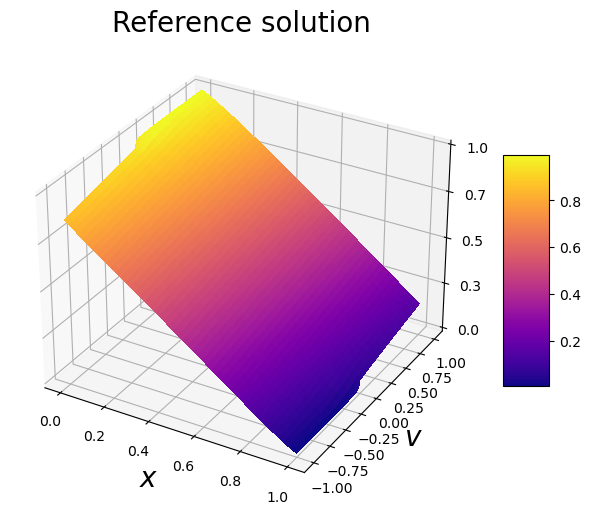

In [9]:
font_format = {"family": "Times New Roman", "size": 20}

fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(1, 1, 1, projection="3d")
surf1 = ax1.plot_surface(X, V, F, cmap="plasma",
                         linewidth=0, antialiased=False)
ax1.set_xlabel(r"$x$", font_format)
ax1.set_ylabel(r"$v$", font_format)
ax1.zaxis.set_major_locator(LinearLocator(5))
ax1.zaxis.set_major_formatter("{x:.01f}")
ax1.set_title("Reference solution", font_format)
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)
fig.colorbar(surf1, shrink=0.5, aspect=5)

plt.show()

findfont: Font family ['Times New Roman'] not found. Falling back to DejaVu Sans.


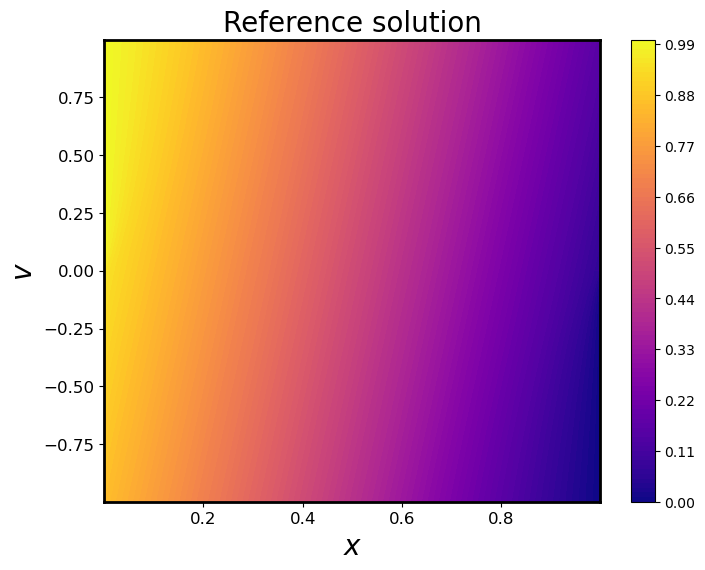

In [10]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.contourf(X, V, F, 100, cmap="plasma")
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.colorbar()
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

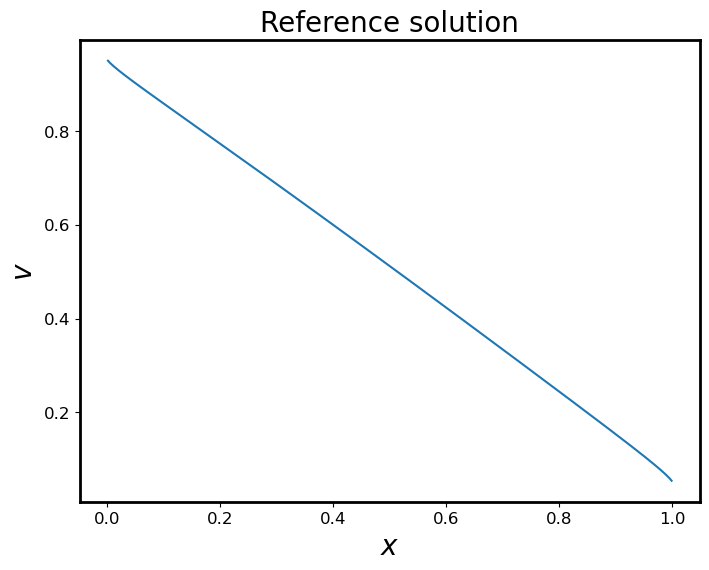

In [11]:
font_format = {"family": "Times New Roman", "size": 20}

plt.figure(figsize=(8, 6))
ax1 = plt.subplot(1, 1, 1)
plt.plot(mesh_x[1:-1], rho)
# font size and type
plt.xticks(fontproperties="Times New Roman", size=12)
plt.yticks(fontproperties="Times New Roman", size=12)
plt.xlabel(r"$x$", font_format)
plt.ylabel(r"$v$", font_format)
plt.title("Reference solution", font_format)
# # line width of four axises
ax1.spines["bottom"].set_linewidth(2)
ax1.spines["left"].set_linewidth(2)
ax1.spines["right"].set_linewidth(2)
ax1.spines["top"].set_linewidth(2)

plt.show()
plt.close()

In [12]:
np.savez(
    f"../data/rte1d_ex2_ref_{kn:.1e}.npz",
    mesh_x=mesh_x[1:-1],
    mesh_v=mesh_v[1:-1],
    F=F,
    rho=rho,
)
print(kn, F.shape)

0.1 (2046, 1023)


In [13]:
# F_exact = 1.0 - X
# E = F - F_exact

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # --- 数值解 ---
# cs0 = axes[0].contourf(X, V, F, 100, cmap="plasma")
# axes[0].set_title("Numerical solution", font_format)
# axes[0].set_xlabel(r"$x$", font_format)
# axes[0].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs0, ax=axes[0])

# # --- 精确解 ---
# cs1 = axes[1].contourf(X, V, F_exact, 100, cmap="plasma")
# axes[1].set_title("Exact solution", font_format)
# axes[1].set_xlabel(r"$x$", font_format)
# axes[1].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs1, ax=axes[1])

# # --- 误差 ---
# cs2 = axes[2].contourf(X, V, E, 100, cmap="coolwarm")
# axes[2].set_title("Error", font_format)
# axes[2].set_xlabel(r"$x$", font_format)
# axes[2].set_ylabel(r"$v$", font_format)
# fig.colorbar(cs2, ax=axes[2])

# plt.tight_layout()
# plt.show()

In [14]:
# # 计算加权 L2 与 L∞ 误差（速度方向用已定义的 weights）
# dx_local = (xmax - xmin) / num_x
# weights_mid = weights[1:-1]  # 与 F_num 的第0维 (v) 对齐
# w2d = weights_mid[:, None] * dx_local  # 2D 权重 = v 权重 × dx

# # L2 相对误差（相对 F_exact）
# num = np.sum((E**2) * w2d)
# den = np.sum((F_exact**2) * w2d) + 1e-16
# rel_L2 = np.sqrt(num / den)

# # L∞ 误差
# linf = np.max(np.abs(E))

# print(f"relative L2 error = {rel_L2:.3e},  Linf = {linf:.3e}")